# AdaDetect (ERM) on Kaggle Cats vs Dogs

**Goal.** Detect novelties in a test set whose *typical* class is **dog** and where ~5% of the items are **cats** (the novelties), using `AdaDetectERM` from Marandon, Lei, Mary & Roquain — *Machine learning meets FDR* (arXiv:2208.06685, repo: `arianemarandon/adadetect`).

**Why this works / score-function choice.**
AdaDetect computes empirical p-values from a single score function and applies a BH-style step that **provably controls FDR** (under exchangeability of the NTS and the test inliers). Power depends on the score function's ability to separate inliers from outliers. The ERM theory in the paper says: if you train a binary classifier to distinguish the *null training sample* (NTS) from the *test mixture*, the resulting class-probability score converges to the likelihood-ratio (Neyman–Pearson optimal) — i.e. the **most powerful** score at any FDR level.

For images, raw pixels make this classifier hopeless, so we use a **frozen pretrained CNN (ResNet50, ImageNet)** to extract features and then plug a strong tabular learner — `HistGradientBoostingClassifier` — into AdaDetect as the `scoring_fn`. This combo (deep features + gradient-boosted ERM head) is what gives high power while AdaDetect handles FDR control.

**Setup.**
- NTS (`xnull`): only dogs.
- Test sample (`x`): 95% dogs + 5% cats.
- Target FDR level: `alpha = 0.1` (configurable).

## Import


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, Subset, ConcatDataset, DataLoader, TensorDataset
from torchvision import datasets, transforms
from medmnist import ChestMNIST, DermaMNIST, BreastMNIST, BloodMNIST, OCTMNIST
from medmnist import INFO

from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from procedure import AdaDetectERM, AdaDetectDE

BASE_SEED = 42
def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_all_seeds(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [2]:
import urllib.request
import pathlib

HERE = pathlib.Path.cwd()
PKG_DIR = HERE / "adadetect_pkg"
PKG_DIR.mkdir(exist_ok=True)

files = {
    "procedure.py": "https://raw.githubusercontent.com/arianemarandon/adadetect/main/procedure.py",
    "algo.py": "https://raw.githubusercontent.com/arianemarandon/adadetect/main/algo.py",
}

for fname, url in files.items():
    fpath = PKG_DIR / fname
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)

init_file = PKG_DIR / "__init__.py"
if not init_file.exists():
    init_file.write_text("# local adadetect package\n", encoding="utf-8")

print("AdaDetect package ready at:", PKG_DIR)
for fname in ["__init__.py", "procedure.py", "algo.py"]:
    p = PKG_DIR / fname
    print("-", p.name, p.exists(), p.stat().st_size if p.exists() else 0)


AdaDetect package ready at: c:\Users\h4sor\OneDrive\Desktop\Bachlor\Soren\Adadetect\adadetect_pkg
- __init__.py True 27
- procedure.py True 11173
- algo.py True 3012


## 1. Download the Kaggle cats-vs-dogs archive

This is the same `kagglecatsanddogs_5340.zip` that Kaggle distributes, hosted by Microsoft Research. After unzipping, images live under `PetImages/Cat/*.jpg` and `PetImages/Dog/*.jpg`. A small number of files are corrupt — we filter them out.

In [3]:
import os, zipfile, requests, pathlib
import numpy as np
from PIL import Image

DATA_DIR = HERE / "cats_vs_dogs"
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / "kagglecatsanddogs_5340.zip"
IMG_ROOT = DATA_DIR / "PetImages"
URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

if not IMG_ROOT.exists():
    if not ZIP_PATH.exists():
        print("Downloading ~800 MB ...")
        with requests.get(URL, stream=True) as r:
            r.raise_for_status()
            with open(ZIP_PATH, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    print("Unzipping ...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

def list_valid(folder):
    paths = []
    for p in sorted(folder.iterdir()):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        try:
            with Image.open(p) as im:
                im.verify()
            paths.append(p)
        except Exception:
            pass
    return paths

cat_paths = list_valid(IMG_ROOT / "Cat")
dog_paths = list_valid(IMG_ROOT / "Dog")
print(f"valid cats: {len(cat_paths)}   valid dogs: {len(dog_paths)}")

c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


valid cats: 12499   valid dogs: 12499


## 2. Extract frozen ResNet50 features

We average-pool the final conv block → 2048-d feature per image. Cache to disk so we only do this once.

In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet101_Weights, resnet101, resnet50, ResNet50_Weights
from tqdm.auto import tqdm

FEAT_PATH = HERE / "cvd_features.npz"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

class ImgDataset(Dataset):
    def __init__(self, paths, label, tf):
        self.paths, self.label, self.tf = paths, label, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), self.label

if not FEAT_PATH.exists():
    weights = ResNet101_Weights.IMAGENET1K_V2
    preprocess = weights.transforms()
    model = resnet101   (weights=weights)
    model.fc = torch.nn.Identity()  # output the 2048-d pooled features
    model.eval().to(DEVICE)

    all_paths   = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
    paths_only  = [p for p, _ in all_paths]
    labels_only = [y for _, y in all_paths]

    ds = ImgDataset(paths_only, 0, preprocess)

    def collate(batch_idx):
        imgs = torch.stack([ds[i][0] for i in batch_idx])
        ys   = torch.tensor([labels_only[i] for i in batch_idx])
        return imgs, ys

    # Use single-worker loading on Windows to avoid DataLoader crashes.
    num_workers = 0 if os.name == "nt" else 4
    loader = DataLoader(
        range(len(paths_only)), batch_size=64, shuffle=False,
        num_workers=num_workers, pin_memory=(DEVICE == "cuda"),
        collate_fn=collate,
    )

    feats, labels = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="extracting"):
            f = model(xb.to(DEVICE)).cpu().numpy()
            feats.append(f)
            labels.append(yb.numpy())

    feats  = np.concatenate(feats).astype(np.float32)
    labels = np.concatenate(labels).astype(np.int64)
    np.savez_compressed(FEAT_PATH, feats=feats, labels=labels)
    print("Saved features:", feats.shape)
else:
    print("Loading cached features from", FEAT_PATH)

data   = np.load(FEAT_PATH)
feats  = data["feats"]
labels = data["labels"]
dogs = feats[labels == 1]
cats = feats[labels == 0]
print("dogs:", dogs.shape, "cats:", cats.shape)


device: cuda
Loading cached features from c:\Users\h4sor\OneDrive\Desktop\Bachlor\Soren\Adadetect\cvd_features.npz
dogs: (12499, 2048) cats: (12499, 2048)


## 3. Build the AdaDetect inputs

- `xnull`: NTS, only dogs.
- `x`: test sample, 95% dogs + 5% cats.

We keep ground-truth labels for the test set so we can compute realized FDR and power.

In [13]:
def build_problem(rng, n_null=4000, m_test=1000, novelty_frac=0.05):
    """Return xnull, x, is_novelty (bool array, True == cat)."""
    m1 = int(round(novelty_frac * m_test))   # cats in test
    m0 = m_test - m1                         # dogs in test
    dog_idx = rng.permutation(len(dogs))
    cat_idx = rng.permutation(len(cats))
    assert len(dog_idx) >= n_null + m0, "not enough dogs"
    assert len(cat_idx) >= m1, "not enough cats"
    xnull = dogs[dog_idx[:n_null]]
    test_dogs = dogs[dog_idx[n_null : n_null + m0]]
    test_cats = cats[cat_idx[:m1]]
    x = np.concatenate([test_dogs, test_cats], axis=0)
    is_novelty = np.concatenate([np.zeros(m0, bool), np.ones(m1, bool)])
    perm = rng.permutation(len(x))           # shuffle so order is not informative
    return xnull, x[perm], is_novelty[perm]

rng = np.random.default_rng(0)
xnull, x, is_novelty = build_problem(rng, novelty_frac=0.3)
print("xnull", xnull.shape, "  x", x.shape, "  novelties in test:", is_novelty.sum())

xnull (4000, 2048)   x (1000, 2048)   novelties in test: 300


## 4. Run AdaDetectERM

`scoring_fn` should be a sklearn-style classifier with `fit` and `predict_proba`. We use **HistGradientBoostingClassifier**: fast, strong on 2048-d ResNet features, and an excellent ERM-class probability estimator. (`RandomForestClassifier(max_depth=10)` — used in the repo example — is a safe alternative; we benchmark both below.)

`split_size` is the fraction of the *combined* `(xnull, x)` used as the calibration set inside AdaDetect (the rest is used to fit the classifier). The paper / repo example uses `split_size = n / (n + len(x_extra))` where `x_extra` is taken from `xnull`. Here a value around `0.7–0.8` works well.

In [14]:
import sys
sys.path.insert(0, str(HERE))
from procedure import AdaDetectERM

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

ALPHA = 0.10   # target FDR level

def fdp_power(rejected_idx, is_novelty):
    R = len(rejected_idx)
    if R == 0:
        return 0.0, 0.0
    tp = int(is_novelty[rejected_idx].sum())
    fp = R - tp
    fdp = fp / R
    power = tp / max(int(is_novelty.sum()), 1)
    return fdp, power

scorers = {
    "HistGBM": HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1, max_iter=200),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, n_jobs=-1),
}

for name, clf in scorers.items():
    proc = AdaDetectERM(scoring_fn=clf, split_size=0.75)
    rejected = proc.apply(x, ALPHA, xnull)
    fdp, power = fdp_power(np.asarray(rejected, dtype=int), is_novelty)
    print(f"{name:>12s}  |R|={len(rejected):4d}   FDP={fdp:.3f}   Power={power:.3f}")


     HistGBM  |R|= 296   FDP=0.030   Power=0.957
RandomForest  |R|= 318   FDP=0.066   Power=0.990


## 5. Repeat over seeds — empirical FDR and power

FDR control is a guarantee *in expectation*. Average over many random splits to confirm FDR ≤ α and to compare scorers on power.

In [15]:
from tqdm.auto import tqdm

N_REPS = 20
results = {name: {"fdp": [], "power": []} for name in scorers}

for seed in tqdm(range(N_REPS)):
    rng = np.random.default_rng(seed)
    xnull_s, x_s, novelty_s = build_problem(rng)
    for name, clf_proto in scorers.items():
        # fresh estimator per run
        clf = clf_proto.__class__(**clf_proto.get_params())
        proc = AdaDetectERM(scoring_fn=clf, split_size=0.75)
        rej = np.asarray(proc.apply(x_s, ALPHA, xnull_s), dtype=int)
        fdp, pw = fdp_power(rej, novelty_s)
        results[name]["fdp"].append(fdp)
        results[name]["power"].append(pw)

print(f"Target FDR alpha = {ALPHA}\n")
print(f"{'scorer':>14s}  {'mean FDR':>10s}  {'mean power':>10s}")
for name, r in results.items():
    print(f"{name:>14s}  {np.mean(r['fdp']):10.3f}  {np.mean(r['power']):10.3f}")

100%|██████████| 20/20 [08:28<00:00, 25.45s/it]

Target FDR alpha = 0.1

        scorer    mean FDR  mean power
       HistGBM       0.075       0.696
  RandomForest       0.079       0.759


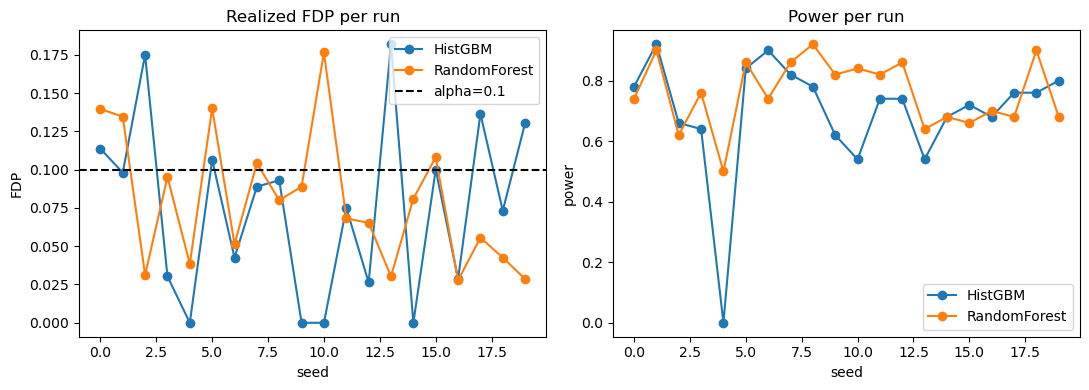

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, r in results.items():
    axes[0].plot(r["fdp"], marker="o", label=name)
    axes[1].plot(r["power"], marker="o", label=name)
axes[0].axhline(ALPHA, color="k", ls="--", label=f"alpha={ALPHA}")
axes[0].set_title("Realized FDP per run"); axes[0].set_xlabel("seed"); axes[0].set_ylabel("FDP"); axes[0].legend()
axes[1].set_title("Power per run"); axes[1].set_xlabel("seed"); axes[1].set_ylabel("power"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Look at the AdaDetect score distribution

Sanity check: the ERM score (probability that a test point comes from the *test mixture* rather than the NTS) should be visibly higher for cats than for dogs.

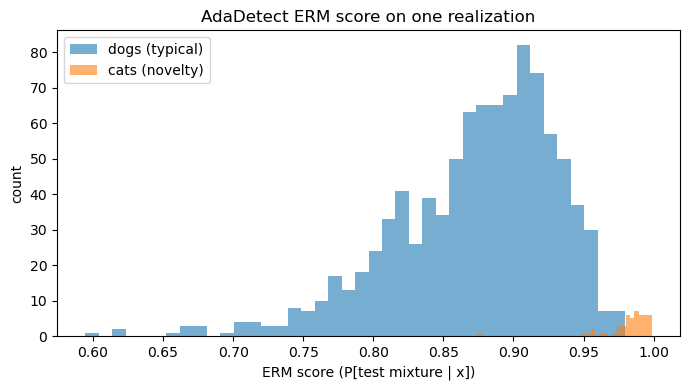

In [17]:
# Reproduce the internal score on one realization for visualization.
rng = np.random.default_rng(123)
xnull_s, x_s, novelty_s = build_problem(rng)

clf = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1, max_iter=200)
# Train: NTS labelled 0, test sample labelled 1 (this is the AdaDetect ERM construction).
X_train = np.concatenate([xnull_s, x_s], axis=0)
y_train = np.concatenate([np.zeros(len(xnull_s)), np.ones(len(x_s))]).astype(int)
clf.fit(X_train, y_train)
scores = clf.predict_proba(x_s)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores[~novelty_s], bins=40, alpha=0.6, label="dogs (typical)")
ax.hist(scores[ novelty_s], bins=40, alpha=0.6, label="cats (novelty)")
ax.set_xlabel("ERM score (P[test mixture | x])"); ax.set_ylabel("count")
ax.set_title("AdaDetect ERM score on one realization")
ax.legend(); plt.tight_layout(); plt.show()

## Notes

- **FDR guarantee.** AdaDetect's BH-on-empirical-p-values controls FDR at level `alpha` whenever the NTS and the test inliers are exchangeable — here trivially satisfied because both are random samples of dogs.
- **Why HistGBM/RF on deep features as the score?** ERM theory: any classifier whose probability output approximates the Bayes optimum yields a power-optimal AdaDetect. Tree ensembles on 2048-d ResNet features approximate it well in practice; raw pixels would not.
- **Tuning knobs:** `split_size` (calibration vs. fitting fraction), the scorer's capacity (`max_depth`, `max_iter`/`n_estimators`), and `alpha`. FDR is preserved across all of these — only power changes.
- **Larger `n_null`** (more dogs in the NTS) lowers the empirical p-value granularity and usually increases power.